In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller
import warnings
# para ocultar adventencias
warnings.filterwarnings('ignore')

In [6]:
sismosdf = pd.read_csv('SSNMX_catalogo_20240101_20251231.csv', skiprows=4)
sismosdf.head()
dimensiones = sismosdf.shape
print(f"Las dimensiones son:{dimensiones}")

Las dimensiones son:(72323, 10)


In [7]:
sismosdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 72323 entries, 0 to 72322
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Fecha                       72323 non-null  str    
 1   Hora                        72316 non-null  str    
 2   Magnitud                    72316 non-null  float64
 3   Latitud                     72316 non-null  float64
 4   Longitud                    72316 non-null  float64
 5   Profundidad                 72316 non-null  float64
 6   Referencia de localizacion  72316 non-null  str    
 7   Fecha UTC                   72316 non-null  str    
 8   Hora UTC                    72316 non-null  str    
 9   Estatus                     72316 non-null  str    
dtypes: float64(4), str(6)
memory usage: 5.5 MB


In [ ]:
#localizar valores faltantes 
faltantes = sismosdf.isnull().sum()
print(faltantes)
#eliminar faltantes
sismosdf = sismosdf.dropna()

Fecha                         0
Hora                          0
Magnitud                      0
Latitud                       0
Longitud                      0
Profundidad                   0
Referencia de localizacion    0
Fecha UTC                     0
Hora UTC                      0
Estatus                       0
dtype: int64


In [12]:
# promediar magnitud x dia
sismosdf['Fecha'] = pd.to_datetime(sismosdf['Fecha'])
sismosdf['Dia'] = sismosdf['Fecha'].dt.date
promedio_magnitud = sismosdf.groupby('Dia')['Magnitud'].mean().reset_index()
print(promedio_magnitud.head())
shape_promedio = promedio_magnitud.shape
print(f"Las dimensiones del promedio son: {shape_promedio}")

          Dia  Magnitud
0  2024-01-01  3.470588
1  2024-01-02  3.471429
2  2024-01-03  3.547115
3  2024-01-04  3.439286
4  2024-01-05  3.580822
Las dimensiones del promedio son: (731, 2)


In [14]:
serie = promedio_magnitud['Magnitud']
serie

0      3.470588
1      3.471429
2      3.547115
3      3.439286
4      3.580822
         ...   
726    3.013793
727    3.134862
728    3.101250
729    3.095122
730    3.153488
Name: Magnitud, Length: 731, dtype: float64

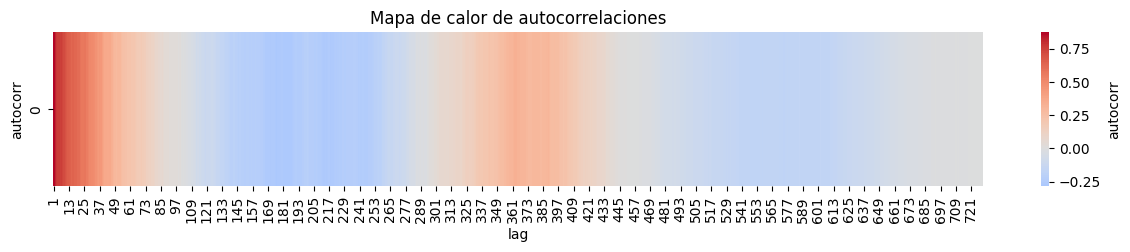

In [15]:
lags = 730
acf_values = acf(serie, nlags= lags)
df_acf = pd.DataFrame(acf_values[1:].reshape(1, -1), 
                      columns=range(1, lags + 1))

plt.figure(figsize=(15, 2))
sns.heatmap(df_acf, annot=False, cmap='coolwarm', center=0,      
            cbar_kws={'label': 'autocorr'})

plt.title('Mapa de calor de autocorrelaciones')
plt.xlabel('lag')
plt.ylabel('autocorr')
plt.show()